In [95]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import pickle

In [36]:
df = pd.read_csv("imdb_movies_2024_5000_clean.csv")

df.head()

,Movie Name,Storyline
0,# 1 Fan,No storyline available
1,#AAY,"When a man comes home between covid lockdowns,..."
2,#AMFAD: All My Friends Are Dead,A group of college friends rent an Airbnb for ...
3,#BFFs,Four girlfriends' weekend getaway takes a dark...
4,#Comicsgate - How to Kill a Movement,No storyline available


In [37]:
df.isnull().sum()

Movie Name    0
Storyline     0
dtype: int64

In [38]:
df.duplicated().sum()

np.int64(0)

In [39]:
df["Movie Name"].duplicated().sum()

np.int64(0)

In [40]:
df[df["Movie Name"].duplicated()]

,Movie Name,Storyline


In [41]:
df["story_length"] = df["Storyline"].apply(len)

df["story_length"].describe()

count    4026.000000
mean      183.383507
std       126.206556
min        22.000000
25%       139.000000
50%       181.000000
75%       220.000000
max      5210.000000
Name: story_length, dtype: float64

In [42]:
df.sort_values("story_length", ascending=False)[["Movie Name","story_length"]].head(10)

,Movie Name,story_length
135,23:47,5210
2633,The Stand,1876
3553,Bahodir Yalangto'sh,1605
3881,Le cinquième plan de La Jetée,1593
3907,Sodade,1507
3349,Nanak Naam Jahaz Hai,1431
3402,Bloody Bridget,991
2790,Wet Dreams,936
3649,Leydi Di,910
2622,Çakallarla Dans 7,901


In [44]:
df.sort_values("story_length")[["Movie Name","story_length"]].head(10)

,Movie Name,story_length
0,# 1 Fan,22
18,(In)Visibles,22
39,1 Thessalonians,22
40,1-800-Missing,22
60,11 Brothers: The Movie,22
63,11.11.18 Soldat Inconnu,22
70,12 Million Dollar Movie on Paper,22
2364,Call of Duty,22
3635,Bocchi the Rock! Live,22
2389,Run Away,22


In [45]:
df = df[df["Storyline"] != "No storyline available"]

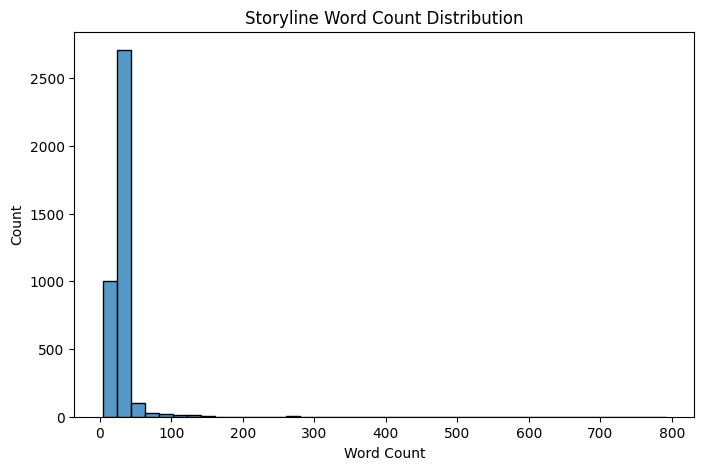

In [46]:
df["word_count"] = df["Storyline"].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8,5))
sns.histplot(df["word_count"], bins=40)
plt.title("Storyline Word Count Distribution")
plt.xlabel("Word Count")
plt.show()

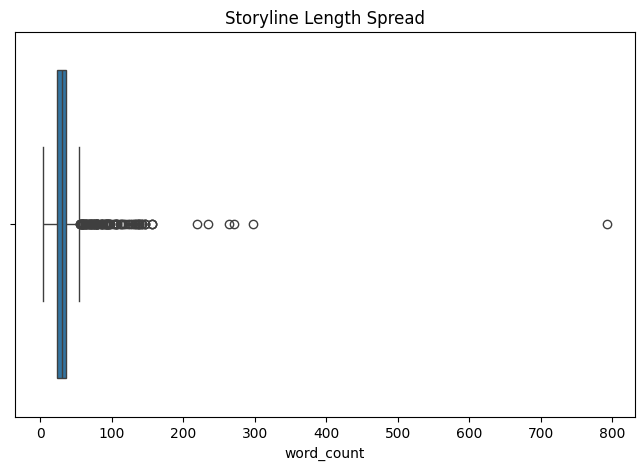

In [47]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["word_count"])
plt.title("Storyline Length Spread")
plt.show()

In [48]:
vectorizer = CountVectorizer(stop_words="english", max_features=20)

X = vectorizer.fit_transform(df["Storyline"])

word_freq = pd.DataFrame({
    "Word": vectorizer.get_feature_names_out(),
    "Count": X.toarray().sum(axis=0)
}).sort_values(by="Count", ascending=False)

word_freq

,Word,Count
6,life,580
0,family,457
8,love,362
19,young,358
9,man,304
11,new,286
16,woman,265
17,world,260
14,story,244
1,father,223


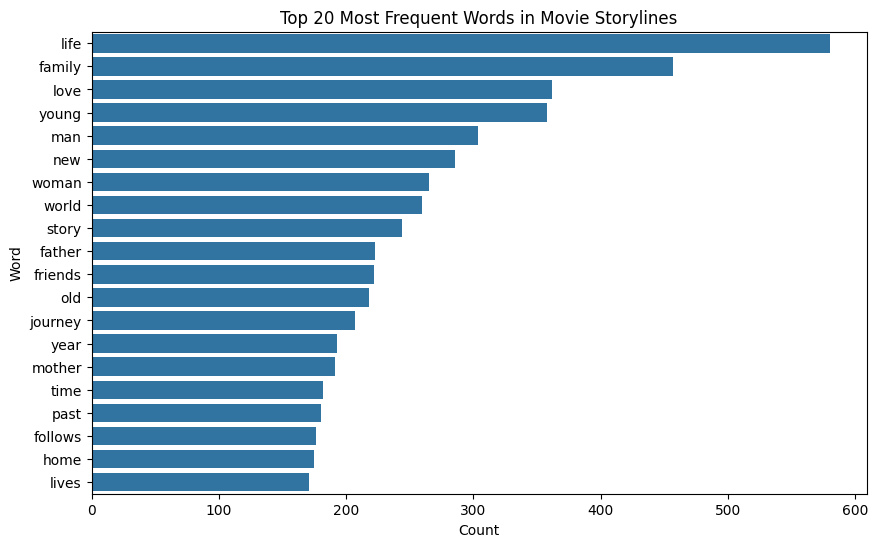

In [49]:
plt.figure(figsize=(10,6))
sns.barplot(x="Count", y="Word", data=word_freq)
plt.title("Top 20 Most Frequent Words in Movie Storylines")
plt.show()

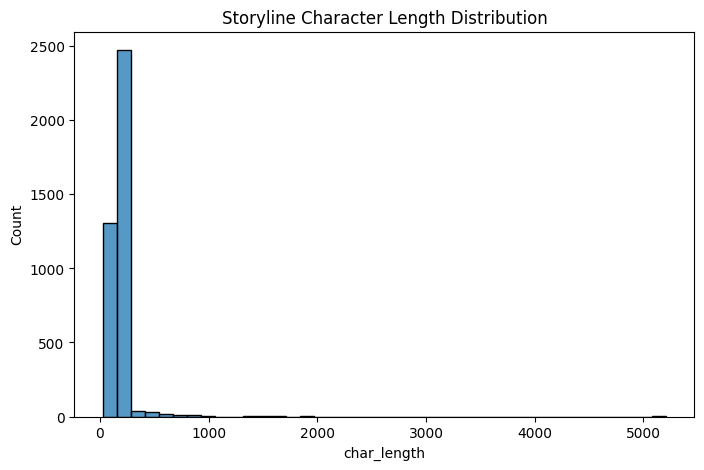

In [50]:
df["char_length"] = df["Storyline"].apply(len)

plt.figure(figsize=(8,5))
sns.histplot(df["char_length"], bins=40)
plt.title("Storyline Character Length Distribution")
plt.show()

In [54]:
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ragav\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [56]:
def clean_text(text):
    
    text = text.lower()                        # lowercase
    
    text = re.sub(r'[^a-zA-Z ]', '', text)     # remove punctuation & numbers
    
    words = text.split()
    
    words = [word for word in words if word not in stop_words]   # remove stopwords
    
    text = " ".join(words)
    
    return text

In [57]:
df["clean_story"] = df["Storyline"].apply(clean_text)

df.head()

,Movie Name,Storyline,story_length,word_count,char_length,clean_story
1,#AAY,"When a man comes home between covid lockdowns,...",152,27,152,man comes home covid lockdowns connects old fr...
2,#AMFAD: All My Friends Are Dead,A group of college friends rent an Airbnb for ...,233,43,233,group college friends rent airbnb biggest musi...
3,#BFFs,Four girlfriends' weekend getaway takes a dark...,202,32,202,four girlfriends weekend getaway takes dark tu...
5,#FamilyMan,One man's world turns upside-down.,34,5,34,one mans world turns upsidedown
6,#Lifestories,A collection of six shorts exploring the range...,153,21,153,collection six shorts exploring range human em...


In [58]:
df = df[df["clean_story"].str.strip() != ""]

In [59]:
df.reset_index(drop=True, inplace=True)

In [60]:
df[["Movie Name","clean_story"]].head()

,Movie Name,clean_story
0,#AAY,man comes home covid lockdowns connects old fr...
1,#AMFAD: All My Friends Are Dead,group college friends rent airbnb biggest musi...
2,#BFFs,four girlfriends weekend getaway takes dark tu...
3,#FamilyMan,one mans world turns upsidedown
4,#Lifestories,collection six shorts exploring range human em...


In [61]:
df.to_csv("cleaned_movies_nlp.csv", index=False)

In [80]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=10000,
    ngram_range=(1,2),
    min_df=2
)

In [81]:
tfidf_matrix = tfidf.fit_transform(df["clean_story"])

In [82]:
tfidf_matrix.shape

(3896, 9441)

In [83]:
tfidf.get_feature_names_out()[:20]

array(['aaron', 'abandon', 'abandoned', 'abandoned convent',
       'abandoned family', 'abandoning', 'abandons', 'abby', 'abducted',
       'abduction', 'abilities', 'ability', 'ablaze', 'able', 'aboard',
       'aboriginal', 'abortion', 'abraham', 'abroad', 'abrupt'],
      dtype=object)

In [84]:
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf.get_feature_names_out()
)

tfidf_df.head()

,aaron,abandon,abandoned,abandoned convent,abandoned family,abandoning,abandons,abby,abducted,abduction,...,yun,zealand,zero,zhang,zoe,zombie,zombie apocalypse,zone,zoo,zoom
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [85]:
similarity = cosine_similarity(tfidf_matrix)

similarity.shape

(3896, 3896)

In [86]:
def recommend_from_storyline_with_score(storyline, top_n=5):

    cleaned = clean_text(storyline)

    input_vector = tfidf.transform([cleaned])

    similarity_scores = cosine_similarity(input_vector, tfidf_matrix)

    scores = list(enumerate(similarity_scores[0]))

    sorted_scores = sorted(scores, key=lambda x: x[1], reverse=True)

    print("Recommended Movies:\n")

    for i in sorted_scores[:top_n]:

        movie_title = df.iloc[i[0]]["Movie Name"]
        score = i[1]

        print(f"{movie_title}  |  Similarity Score: {score:.4f}")

In [87]:
# Save TF-IDF model
pickle.dump(tfidf, open("tfidf_model.pkl", "wb"))

# Save TF-IDF matrix
pickle.dump(tfidf_matrix, open("tfidf_matrix.pkl", "wb"))

# Save dataset
pickle.dump(df, open("movies_df.pkl", "wb"))

In [88]:
story = "A group of astronauts travel through space to save humanity"

recommend_from_storyline_with_score(story)

Recommended Movies:

Tales Beyond the Galaxy  |  Similarity Score: 0.3194
Ghost Planet  |  Similarity Score: 0.2937
Space Ranger  |  Similarity Score: 0.2310
The Fix  |  Similarity Score: 0.2211
Alienoid: The Return to the Future  |  Similarity Score: 0.2208


In [91]:
# number of clusters
k = 5

kmeans = KMeans(n_clusters=k, random_state=42)

clusters = kmeans.fit_predict(tfidf_matrix)

# add cluster labels to dataframe
df["cluster"] = clusters

df.head()

,Movie Name,Storyline,story_length,word_count,char_length,clean_story,cluster
0,#AAY,"When a man comes home between covid lockdowns,...",152,27,152,man comes home covid lockdowns connects old fr...,0
1,#AMFAD: All My Friends Are Dead,A group of college friends rent an Airbnb for ...,233,43,233,group college friends rent airbnb biggest musi...,0
2,#BFFs,Four girlfriends' weekend getaway takes a dark...,202,32,202,four girlfriends weekend getaway takes dark tu...,1
3,#FamilyMan,One man's world turns upside-down.,34,5,34,one mans world turns upsidedown,3
4,#Lifestories,A collection of six shorts exploring the range...,153,21,153,collection six shorts exploring range human em...,1


In [92]:
cluster_counts = df["cluster"].value_counts().sort_index()

cluster_counts

cluster
0     294
1    2663
2     420
3     210
4     309
Name: count, dtype: int64

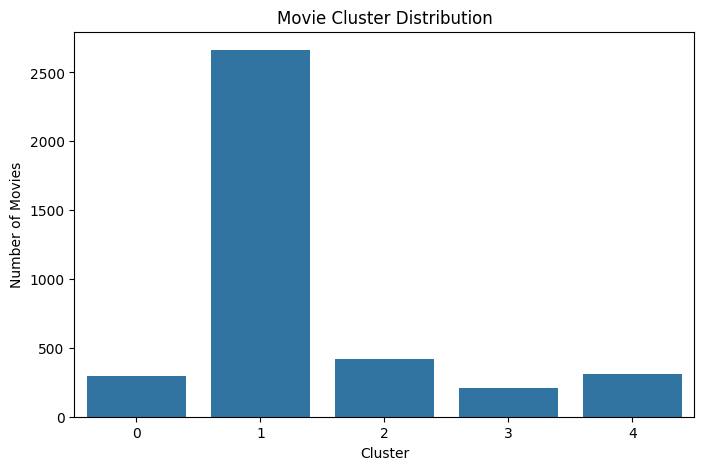

In [93]:
plt.figure(figsize=(8,5))

sns.countplot(x="cluster", data=df)

plt.title("Movie Cluster Distribution")
plt.xlabel("Cluster")
plt.ylabel("Number of Movies")

plt.show()

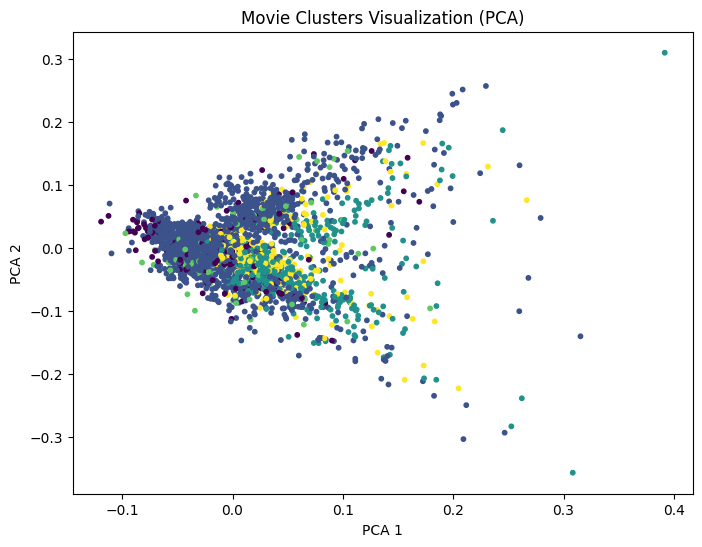

In [96]:
pca = PCA(n_components=2)

reduced = pca.fit_transform(tfidf_matrix.toarray())

plt.figure(figsize=(8,6))

plt.scatter(reduced[:,0], reduced[:,1], c=df["cluster"], cmap="viridis", s=10)

plt.title("Movie Clusters Visualization (PCA)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.show()